In [1]:
# ensure classes imported from .py files are dynamically updated
%load_ext autoreload
%autoreload 2

# plot matplots nicely
%matplotlib inline  

In [2]:
from stericheight.data_handler import *
from stericheight.plotting_fns import PlottingFns
from stericheight.utils import Utils
from load_meop import MEOP
from region import Region
from composite import Composite
pfns = PlottingFns()

In [3]:
import gsw
import cmocean
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.optimize import root_scalar


In [4]:
extent_mertz =[138.5,143,-67,-65.6]

In [5]:
fname = '../data/qc_profile_ds_2dbar.nc'
ds = xr.open_dataset(fname).swap_dims({'n_prof':'time'})

In [6]:
ds = ds.where(
    (ds.lon > extent_mertz[0]) &
    (ds.lon < extent_mertz[1]) &
    (ds.lat > extent_mertz[2]) &
    (ds.lat < extent_mertz[3]), drop=True
)

In [7]:
ds = ds.sel(pres=slice(0,100))

In [8]:
ds=ds.where(~(ds.dsource == 'MEOP'),drop=True)

In [9]:
sice_ = xr.open_dataset('../data/NSIDC/sice_processed.nc').__xarray_dataarray_variable__
winds_ = xr.open_dataset('ef25db236e60a21a34ee2e0b4631d366.nc').sortby('latitude').rename({'valid_time':'time'})
sam = Index(type='SAM').da

In [10]:
sla = SLA(deg=0.25).da
def sanom(da):
    return da.groupby('time.month') - da.groupby('time.month').mean()


In [11]:
pressure_axis = ds.pres.values #np.arange(4,102,2)

In [12]:
meop=MEOP(extent=extent_mertz)
meop.load_profiles_for_spira(pressure_axis=pressure_axis)

100%|██████████| 81/81 [02:10<00:00,  1.61s/it]
/nfs/b0133/eejco/chapter_2/load_meop.py:114: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArray or Variable constructor; it can be silenced by converting the values to nanosecond precision ahead of time.
  self.ds = xr.Dataset.from_dict({


In [13]:
ds_all = xr.merge([meop.ds.drop_duplicates(dim='time'),ds])

In [14]:
ds_all

<xarray.Dataset> Size: 13MB
Dimensions:       (pres: 51, time: 9010)
Coordinates:
  * pres          (pres) int64 408B 0 2 4 6 8 10 12 14 ... 88 90 92 94 96 98 100
  * time          (time) datetime64[ns] 72kB 2007-02-20T15:19:59 ... 2024-02-...
    lat           (time) float64 72kB -66.62 -66.56 -66.59 ... -66.61 -66.61
    lon           (time) float64 72kB 139.9 140.0 140.0 ... 140.0 139.8 139.8
    n_prof        (time) float64 72kB nan nan nan nan nan ... nan nan nan nan
Data variables:
    profile_code  (time) object 72kB 'wd3-CTD2-07' ... 'wd30-639-Vert-22'
    temp          (time, pres) float64 4MB nan nan nan ... -1.253 -1.253 -1.252
    psal          (time, pres) float64 4MB nan nan nan nan ... 34.2 34.2 34.2
    dsource       (time) object 72kB 'MEOP-' 'MEOP-' 'MEOP-' ... 'MEOP-' 'MEOP-'
    mld           (time) float64 72kB nan nan nan nan nan ... nan nan nan nan
    asal          (time, pres) float32 2MB nan nan nan nan ... nan nan nan nan
    ctemp         (time, pres) float32 2MB nan nan nan nan ... nan nan nan nan
    rho           (time, pres) float32 2MB nan nan nan nan ... nan nan nan nan
    mlp           (time) float64 72kB nan nan nan nan nan ... nan nan nan nan

In [14]:
elevation = GEBCO(coarsen_factor=40).ds.elevation
extent =[100,160,-69,-63]
shelf = Region('EA Shelf',extent,elevation,min_elevation=-1000)
mertz = Region('Mertz',extent_mertz)

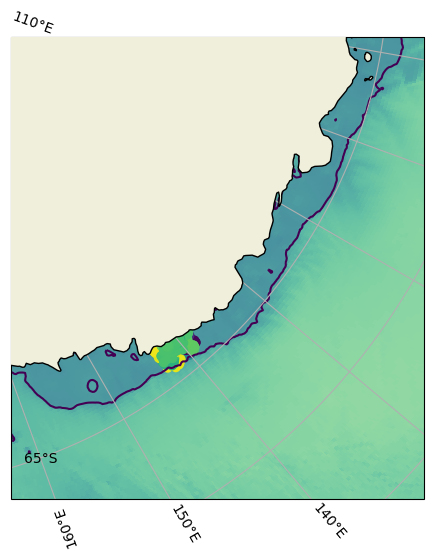

In [15]:
fig,ax=plt.subplots(figsize=(8,6),subplot_kw={'projection':ccrs.SouthPolarStereo()})
pfns.sp(ax,elevation,extent=extent,cmap=cmocean.cm.deep,land_zorder=3)
im=ax.scatter(meop.ds.lon,meop.ds.lat,c=meop.ds.time,transform=ccrs.PlateCarree())
ax.contour(elevation.longitude,elevation.latitude, elevation,levels=[-1000],transform=ccrs.PlateCarree())

In [16]:
meop.ds['month'] = meop.ds.time.dt.month

In [17]:
def get_seasons(dspira_mertz):
    seasons={}
    seasons['autumn']=dspira_mertz.where(((dspira_mertz.month >= 4) & (dspira_mertz.month <= 6)),drop=True)
    seasons['winter']=dspira_mertz.where(((dspira_mertz.month >= 7) & (dspira_mertz.month <= 9)),drop=True)
    seasons['spring']=dspira_mertz.where(((dspira_mertz.month >= 10) & (dspira_mertz.month <= 12)),drop=True)
    seasons['summer']=dspira_mertz.where(((dspira_mertz.month >= 1) & (dspira_mertz.month <= 3)),drop=True)
    return seasons
seasons = get_seasons(meop.ds)
print(len(seasons['autumn'].time))
print(len(seasons['winter'].time))
print(len(seasons['spring'].time))
print(len(seasons['summer'].time))


3659
1151
1607
2997


In [18]:
sla_idx_data = sanom(mertz.crop_da(sla)).mean(['latitude','longitude'])
sla_idx_data = utls.detrend_dim(sla_idx_data,'time')

In [19]:
sic_idx_data = sanom(mertz.crop_da(sice_)).mean(['latitude','longitude'])
sic_idx_data = utls.detrend_dim(sic_idx_data,'time')

In [20]:
sam_idx_data = sanom(sam)
sam_idx_data = utls.detrend_dim(sam_idx_data,'time')

In [35]:
np.arange(2) + 1

array([1, 2])

In [36]:
cmp = Composite(sam_idx_data,'test')
cmp.idx_positive

idx_positive_with_lag = cmp.idx_positive.copy()

In [50]:
cmp.idx_positive.to_numpy()[100:140]

array([False,  True, False, False, False,  True,  True, False, False,
       False, False, False, False, False, False,  True, False,  True,
       False, False, False, False,  True, False, False,  True,  True,
        True,  True,  True, False, False, False, False, False, False,
       False, False,  True, False])

In [51]:
idx_positive_with_lag.to_numpy()[100:140]

array([False,  True,  True,  True, False,  True,  True,  True,  True,
       False, False, False, False, False, False,  True,  True,  True,
        True,  True, False, False,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True, False, False, False, False,
       False, False,  True,  True])

In [48]:

for n in (np.arange(2) + 1):
    shifted_arr = cmp.idx_positive.shift({'time':n},0)
    idx_positive_with_lag = idx_positive_with_lag | shifted_arr

In [45]:
~(cmp.idx_positive) & (cmp.idx_positive.shift({'time':3},fill_value=0))

<xarray.DataArray (time: 780)> Size: 780B
array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False,  True, False, False, False, False, False,
       False, False, False, False, False, False, False, False,  True,
        True,  True, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False,  True, False,
       False, False, False, False,  True,  True,  True, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False,  True,  True,  True,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
...
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False,  True,  True,  True, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False,  True,  True,  True, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
        True,  True, False, False, False, False, False,  True,  True,
        True, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False,  True,  True,  True, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False,  True,  True, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
        True, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False,  True,  True,  True, False, False])
Coordinates:
    month    (time) int64 6kB 1 2 3 4 5 6 7 8 9 10 11 ... 3 4 5 6 7 8 9 10 11 12
  * time     (time) datetime64[ns] 6kB 1957-08-01 1957-09-01 ... 2022-07-01

In [80]:
cmp.idx_positive_without_lag.to_numpy()[175:]

array([ True,  True, False, False, False, False, False, False,  True,
        True, False, False, False, False, False, False, False, False,
       False, False, False, False, False,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False])

In [81]:
cmp.idx_positive_with_lag.to_numpy()[175:]

array([ True,  True,  True,  True,  True, False, False, False,  True,
        True,  True,  True,  True, False, False, False, False, False,
       False, False, False, False, False,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False])

In [74]:
lagwindow=3
arr=cmp.idx_positive_without_lag.copy()
for n in (np.arange(lagwindow) + 1):
    shifted_arr = cmp.idx_positive_without_lag.shift({'time':n},0)
    arr = arr | shifted_arr


In [66]:
cmp.idx_positive_with_lag.to_numpy()[175:]

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True, False, False,
       False, False, False, False, False,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False])

preparing data


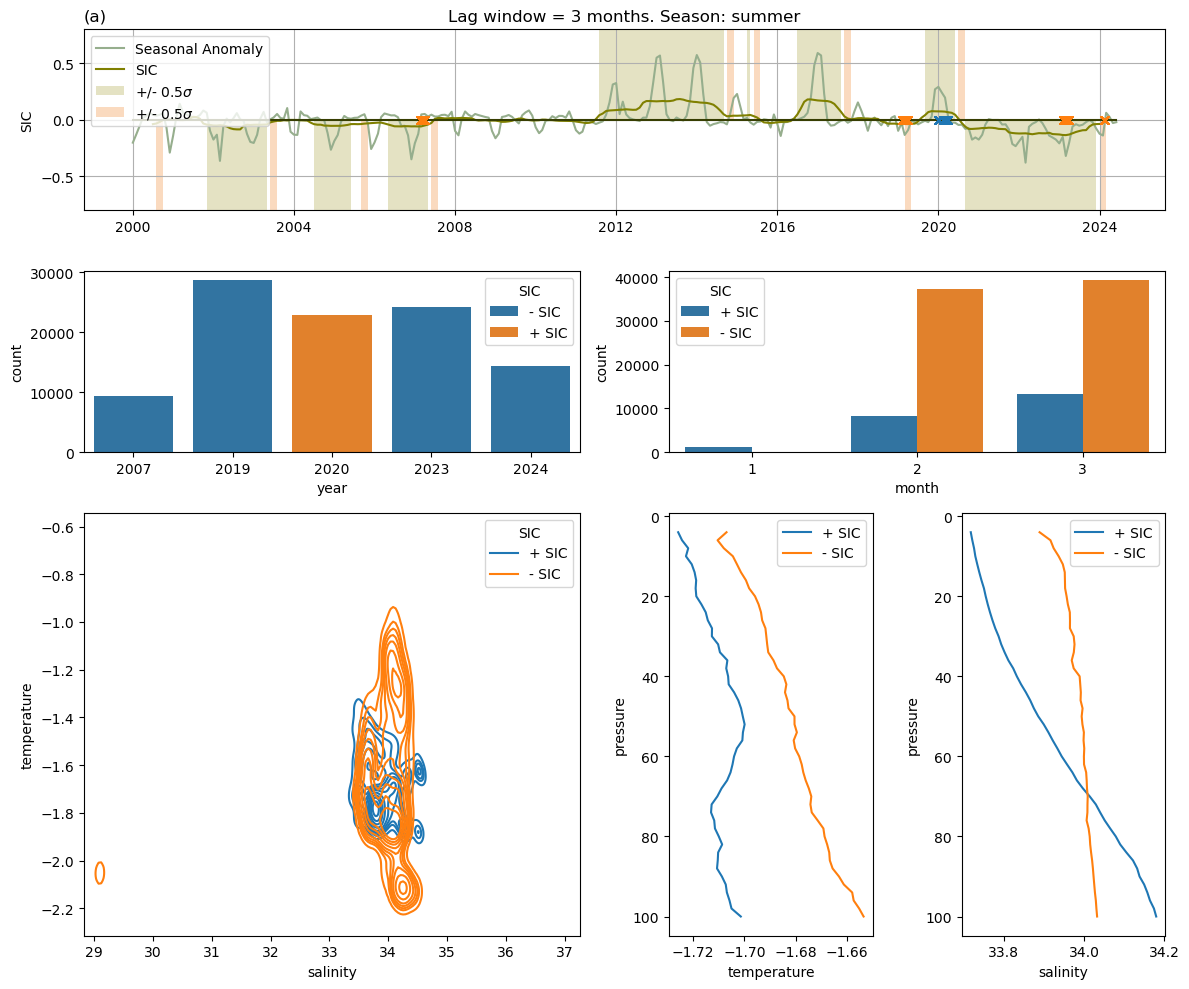

In [79]:
season='summer'
background_data = sic_idx_data
idx_data = background_data.rolling(time=12,center=True).mean('time')
title='SIC'
ylim=[-0.8,0.8]
cmp = Composite(idx_data,title,lagwindow=3)
cmp.add_spira(seasons[season],tlims=[-2.5,0],slims=[33.2,34.8])
cmp.build_sns_data()

fig = plt.figure(figsize=(12,10))
gs = fig.add_gridspec(4,4)

# FIG1: SLA/SAM TIMESERIES
ax1 = fig.add_subplot(gs[0, :])
cmp.composite_timeseries(ax1,background_data,bg_name='Seasonal Anomaly',ylim=ylim)
ax1.set_title('Lag window = {0} months. Season: {1}'.format(3,season))

# FIG2/3 month/year plots
ax2 = fig.add_subplot(gs[1, 0:2])
ax3 = fig.add_subplot(gs[1, 2:4])
sns.countplot(cmp.sns_data, x='year', hue=cmp.idx_name,ax=ax2)
sns.countplot(cmp.sns_data, x='month', hue=cmp.idx_name,ax=ax3)

ax4 = fig.add_subplot(gs[2:4,0:2])
sns.kdeplot(ax=ax4,data=cmp.sns_data,x='salinity',y='temperature',hue=cmp.idx_name)

ax5 = fig.add_subplot(gs[2:4,2])
ax5.plot(cmp.ds_pos.temp.mean('time'),cmp.ds_pos.pressure,label='+ {}'.format(title))
ax5.plot(cmp.ds_neg.temp.mean('time'),cmp.ds_neg.pressure,label='- {}'.format(title))
ax5.set_ylabel('pressure')
ax5.set_xlabel('temperature')
ax5.invert_yaxis()
ax5.legend()

ax6 = fig.add_subplot(gs[2:4,3])
ax6.plot(cmp.ds_pos.psal.mean('time'),cmp.ds_pos.pressure,label='+ {}'.format(title))
ax6.plot(cmp.ds_neg.psal.mean('time'),cmp.ds_neg.pressure,label='- {}'.format(title))
ax6.set_ylabel('pressure')
ax6.set_xlabel('salinity')
ax6.invert_yaxis()
ax6.legend()

plt.tight_layout()